<!-- # Lightweight Grid Calibration Notebook

This notebook compares synthetic and real grids using the exported CSV metrics only.

It keeps status-stratified diagnostics at the top as a check, but uses the full synthetic export for the main representativeness comparison. Normalized Wasserstein distance is the primary score, and feeder count is shown together with buildings per feeder. -->

In [ ]:
import importlib
import sys
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = (project_root / ".." / "..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

scoring = importlib.import_module("validations.grid_comparison.scoring")
scoring = importlib.reload(scoring)
comparison_notebook = importlib.import_module("validations.grid_comparison.comparison_notebook")
comparison_notebook = importlib.reload(comparison_notebook)

DEFAULT_LABELS = comparison_notebook.DEFAULT_LABELS
DEFAULT_METRICS = comparison_notebook.DEFAULT_METRICS
default_metric_filenames = comparison_notebook.default_metric_filenames
selected_metric_filenames = comparison_notebook.selected_metric_filenames
load_and_render_overview = comparison_notebook.load_and_render_overview
plot_boxplot_overview = comparison_notebook.plot_boxplot_overview
plot_metric_kde_diagonal = comparison_notebook.plot_metric_kde_diagonal
plot_scenario_kde_diagonal = comparison_notebook.plot_scenario_kde_diagonal
show_cable_type_comparison = comparison_notebook.show_cable_type_comparison
show_distribution_selector = comparison_notebook.show_distribution_selector
show_wasserstein_summary = comparison_notebook.show_wasserstein_summary

METRICS_ROOT = project_root / "validations" / "metrics"
METRICS_DIR = METRICS_ROOT / "aligned_clean_buildings_91301_version_6_refine_v2"
SYNTHETIC_METRICS_FILE = "synthetic_grid_metrics_aligned_buildings.csv"
REAL_METRICS_FILE = "real_grid_metrics_aligned_coverage.csv"
SYNTHETIC_METRICS_FILE, REAL_METRICS_FILE = selected_metric_filenames(
    SYNTHETIC_METRICS_FILE,
    REAL_METRICS_FILE,
    METRICS_DIR,
)
METRICS = list(DEFAULT_METRICS)
LABELS = dict(DEFAULT_LABELS)
PALETTE = {"Synthetic": "steelblue", "Real": "crimson", "SWF": "darkorange"}
INCLUDE_SWN = False
SWN_METRICS_FILE = None  # Set INCLUDE_SWN = True to opt into SWN metrics.
PLZ = 91301
REAL_GRID_DIR = None  # None uses GRID_DATA_PATH and GRID_SPLIT_SUBDIR from the project .env

In [2]:
notebook_data = load_and_render_overview(
    metrics_dir=METRICS_DIR,
    metrics=METRICS,
    labels=LABELS,
    synthetic_metrics_filename=SYNTHETIC_METRICS_FILE,
    real_metrics_filename=REAL_METRICS_FILE,
)

### Data Inputs

,source,path,rows
0,Synthetic,/home/breveron/git/github/diss/pylovo/validati...,46
1,Real,/home/breveron/git/github/diss/pylovo/validati...,49


### Status-Stratified Diagnostics

,power_flow_status,count
0,converged,45
1,voltage_violation,1


,power_flow_status,synthetic_n,real_n,mean_normalized_wasserstein,median_normalized_wasserstein,worst_metric,worst_normalized_wasserstein
0,converged,45,49,0.3502,0.3371,max_trafo_distance,0.5699
1,voltage_violation,1,49,0.8718,0.8416,graph_resistance,1.2531


### Primary Wasserstein Score

,metric,synthetic_n,real_n,wasserstein_distance,normalized_wasserstein,quality
0,transformer_mva,46,49,0.0282,0.1224,good
1,graph_length,46,49,0.2216,0.1810,good
2,graph_resistance,46,49,0.0680,0.2405,good
3,feeder_lines,46,49,2.0683,0.4137,acceptable
4,avg_trafo_distance,46,49,0.0801,0.5053,poor
5,max_trafo_distance,46,49,0.1570,0.5429,poor


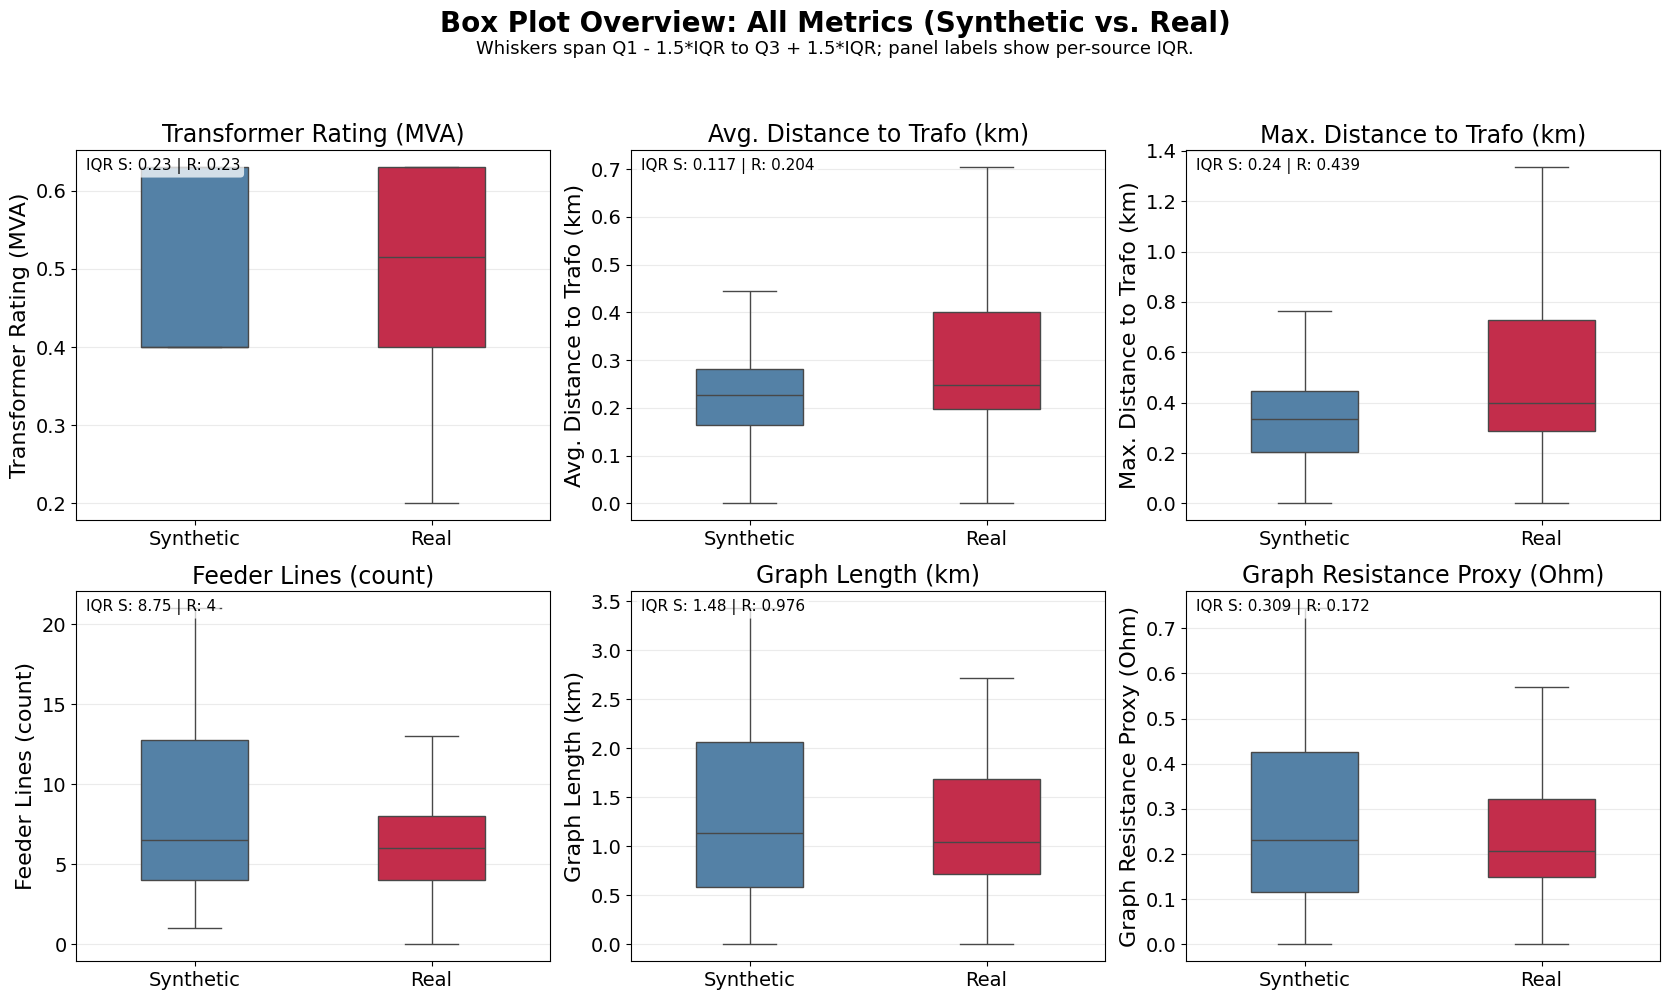

In [3]:
_ = plot_boxplot_overview(
    notebook_data.df_all,
    notebook_data.metrics,
    labels=notebook_data.labels,
    palette=PALETTE,
    title="Box Plot Overview: All Metrics (Synthetic vs. Real)",
    save_path="output/box.pdf", # e.g. METRICS_DIR / "boxplot_overview.svg" or .pdf
)

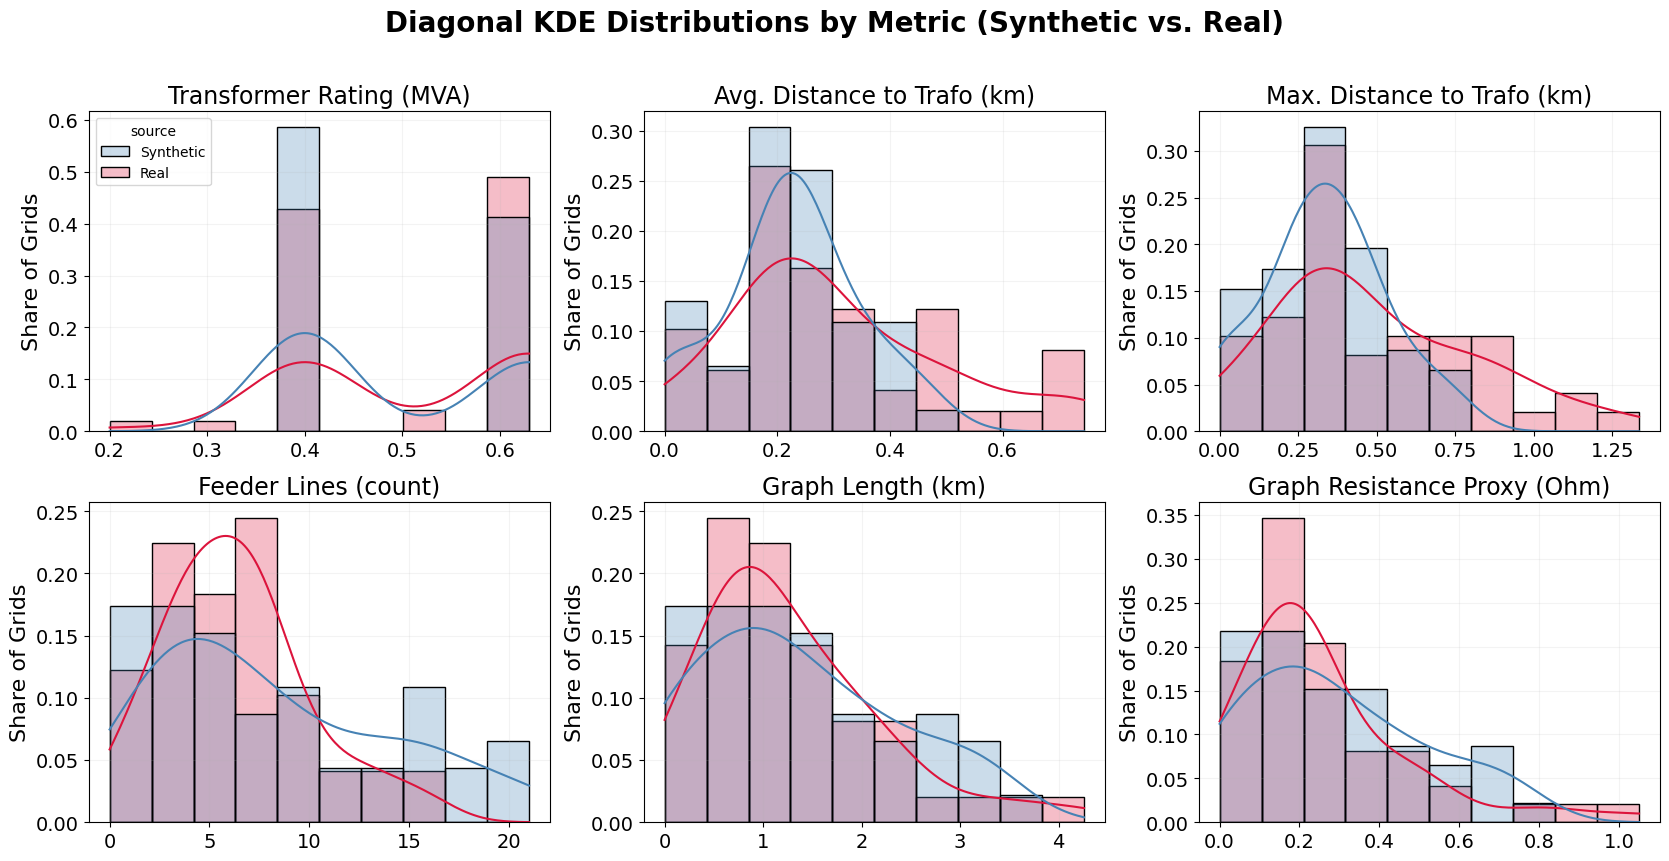

In [4]:
_ = plot_metric_kde_diagonal(
    notebook_data.df_all,
    notebook_data.metrics,
    labels=notebook_data.labels,
    palette=PALETTE,
    show_hist_bars=True,
    bins=10,
    n_cols=3,
    title="Diagonal KDE Distributions by Metric (Synthetic vs. Real)",
    upper_percentile=KDE_UPPER_PERCENTILE if "KDE_UPPER_PERCENTILE" in globals() else None,
    clip_nonnegative=True,
    save_path="output/metric_kde_diagonal.pdf",  # e.g. METRICS_DIR / "metric_kde_diagonal.svg" or .pdf
)

<!-- ### Scenario KDE Comparison

KDE-only comparison of all four synthetic scenario distributions against one real reference distribution. -->


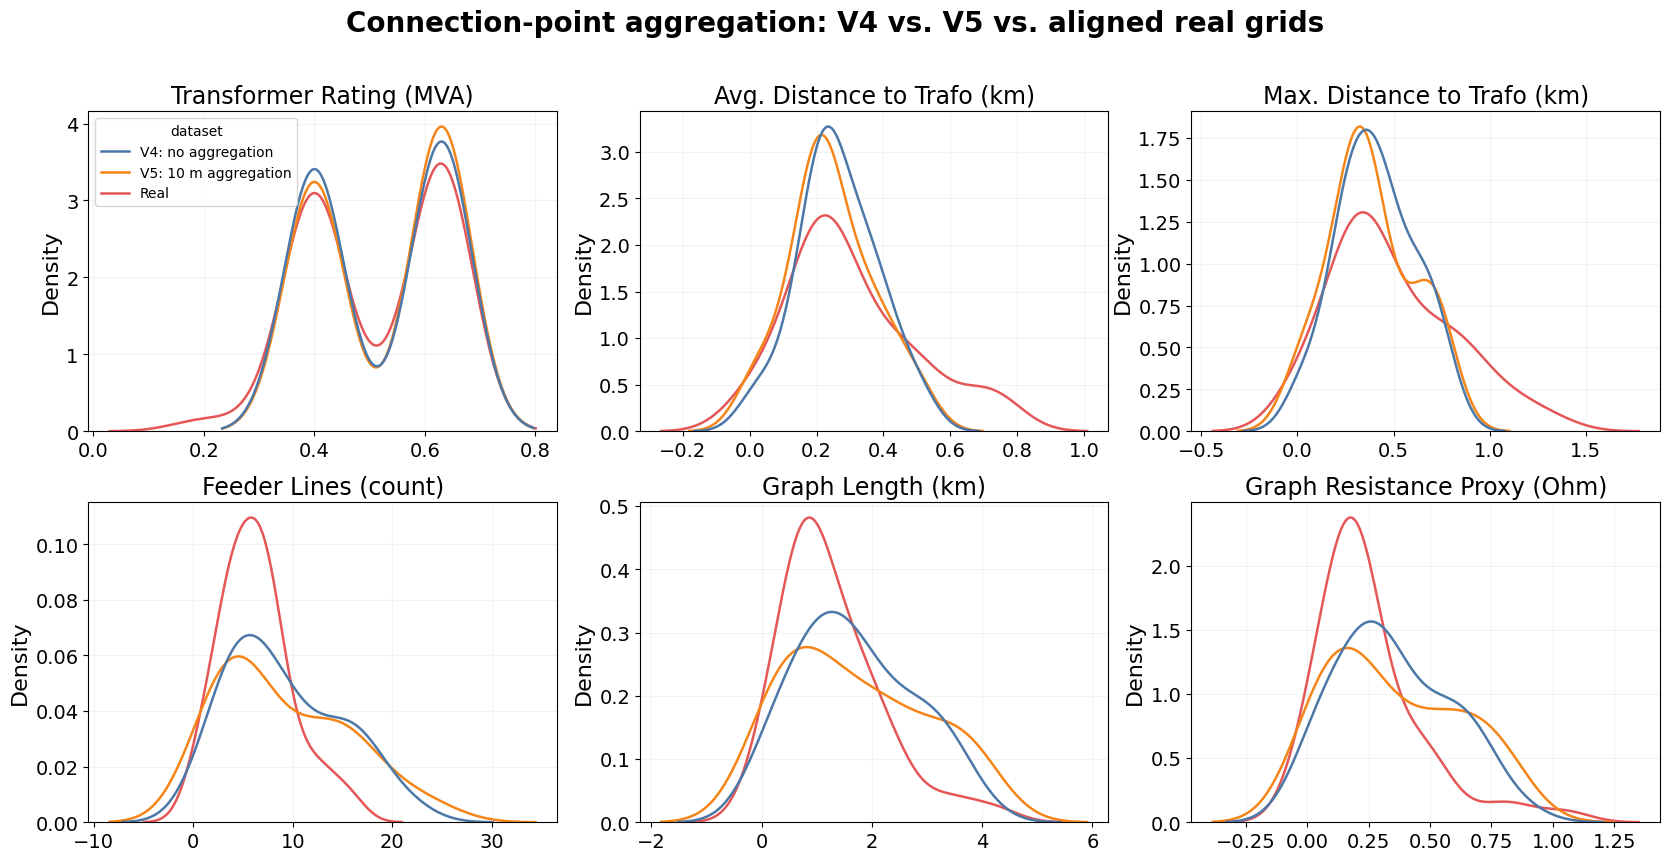

In [5]:
SCENARIO_METRIC_FILES = {
    "Greenfield only": "synthetic_grid_metrics_s1dvgf.csv",
    "Open brownfield": "synthetic_grid_metrics_s2dvop.csv",
    "DSO transformers": "synthetic_grid_metrics_s3dsoimp.csv",
    "Brownfield full": "synthetic_grid_metrics_s4ha150.csv",
}

SCENARIO_PALETTE = {
    "Greenfield only": "#4C78A8",
    "Open brownfield": "#F58518",
    "DSO transformers": "#54A24B",
    "Brownfield full": "#B279A2",
    "Real": "#E45756",
}

_ = plot_scenario_kde_diagonal(
    SCENARIO_METRIC_FILES,
    METRICS,
    metrics_dir=METRICS_DIR,
    real_metrics_filename=REAL_METRICS_FILE,
    labels=LABELS,
    palette=SCENARIO_PALETTE,
    n_cols=3,
    title="KDE Distributions by Scenario (Synthetic vs. real DSO grid data)",
    upper_percentile=1,
    clip_nonnegative=False,
)

In [6]:
show_cable_type_comparison(
    PLZ,
    version_id="7",
    real_grid_dir=REAL_GRID_DIR,
    min_segment_count=0,
)

Showing cable types with more than 0 weighted line segments across real and synthetic grids. `segment_count` counts every in-service `net.line` segment between modeled nodes; parallel circuits contribute via their `parallel` multiplier, so this is not a whole-feeder count.

,std_type,source,segment_count,total_length_km,impedance_ohm_per_km
0,NS-Leitungstyp_fiktiv,Real,878.0,8.041,0.0000
1,NS-Leitungstyp_fiktiv_air,Real,3.0,0.250,0.0000
2,NYY-J 3x240SM 0.6/1kV,Real,18.0,1.119,0.1063
3,NYY-O 3x240SM 0.6/1kV,Real,10.0,0.052,0.1063
4,NYY-J 3x185SM 0.6/1kV,Real,79.0,5.712,0.1250
...,...,...,...,...,...
68,NYY 4x4,Real,3.0,0.046,4.6147
69,NYY 4x2.5,Real,4.0,0.187,7.4141
70,NYM 4x1.5,Real,1.0,0.001,12.1192
71,NYY 3x1.5,Real,4.0,0.016,12.1192
